# Phase 2 — EDA: does the CAMEL feature table make sense?
### Thin walkthrough notebook — the real logic lives in `src/camel_sentinel/`

**What this notebook does**: loads the CAMEL ratio table built in Phase 1, looks at each component's distribution, checks for missing data, and confirms the composite score actually separates failed banks from healthy ones before any model is trained on it.

**Why this matters**: EDA is the checkpoint between "we engineered some features" and "we trust these features enough to model on them" — see "EDA" in [`../docs/01_glossary.md`](../docs/01_glossary.md).

**Where to look for more context**:
- [`../docs/00_problem_statement.md`](../docs/00_problem_statement.md) — success criteria this EDA checks against
- [`../src/camel_sentinel/features/camel_ratios.py`](../src/camel_sentinel/features/camel_ratios.py) — how each column below was built


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

SRC_PATH = str(Path("..").resolve() / "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from camel_sentinel.data import fdic_client
from camel_sentinel.features import camel_ratios

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
print("Environment ready.")


Environment ready.


## 1. Load the CAMEL feature table

Same Phase 1 pipeline as `00_dataset_research.ipynb` — pull (or synthesize) data, build ratios, score the composite. Kept together in one cell here since Phase 1 already walked through each step individually.

In [2]:
institutions, financials, failures, live_ok = fdic_client.try_live_pull()
if not live_ok:
    institutions, financials, failures = fdic_client.build_synthetic_sample()

camel = camel_ratios.score_composite(
    camel_ratios.build_camel_ratios(institutions, financials, failures)
)
print(f"{len(camel)} bank-quarters, {camel['failed'].sum()} flagged failed "
      f"({camel['failed'].mean():.1%}).")
camel.head()


4658 bank-quarters, 15 flagged failed (0.3%).


,CERT,NAME,STALP,ASSET,tier1_ratio,npl_ratio,provision_ratio,efficiency_ratio,roa,roe,nim,loan_deposit_ratio,liquid_asset_ratio,loan_concentration,failed,z_capital,z_asset_quality,z_management,z_earnings,z_liquidity,z_sensitivity,composite_z,composite_score_0_100,proxy_rating_1_5
0,10004,Ergo Bank,WI,240478,9.76,0.530194,1457.0,66.728579,0.893430,9.84,3.727746,99.118581,NaN,79.215562,0,-0.843271,-0.155536,0.068055,-0.060474,NaN,-0.922276,-0.382700,29.0,5
1,10011,Woodford State Bank,WI,442468,10.67,0.913060,1918.0,74.865952,0.748840,15.54,3.134537,88.020311,NaN,68.049893,0,-0.741189,-0.667927,-0.137688,-0.083230,NaN,-0.318441,-0.389695,29.0,5
2,10012,The Portage County Bank,WI,222026,NaN,0.515255,1151.0,77.011853,0.618052,6.18,2.909937,59.149344,NaN,49.983335,0,NaN,-0.135543,-0.191944,-0.103815,NaN,0.658592,0.056823,31.2,2
3,10015,Security Bank,WI,181780,NaN,0.652437,1778.0,58.105355,1.232162,9.95,3.827291,101.450559,NaN,85.067114,0,NaN,-0.319134,0.286082,-0.007162,NaN,-1.238726,-0.319735,29.3,5
4,10044,National Exchange Bank and Trust,WI,2786163,NaN,1.620221,52166.0,47.602329,1.481281,9.58,3.712141,74.429198,NaN,58.878680,0,NaN,-1.614322,0.551637,0.032046,NaN,0.177535,-0.213276,29.8,4


## 2. Missingness audit

Real Call Report data has vintage-dependent gaps (some fields, like a precomputed liquid-asset ratio, aren't available in every quarter/format). Check before modeling — a silently-imputed column can hide a data-quality problem.

In [3]:
feature_cols = ["tier1_ratio", "npl_ratio", "efficiency_ratio",
                "roa", "loan_deposit_ratio", "loan_concentration"]
missing = camel[feature_cols].isna().mean().sort_values(ascending=False) * 100
missing.to_frame("pct_missing")


,pct_missing
tier1_ratio,36.496350
loan_deposit_ratio,1.202233
npl_ratio,0.000000
efficiency_ratio,0.000000
roa,0.000000
loan_concentration,0.000000


## 3. Component distributions

One histogram per CAMEL ratio — sanity-check that each looks like a plausible financial ratio (no impossible negative percentages, no single-value columns, no obvious unit mismatch) before trusting it as a model feature.

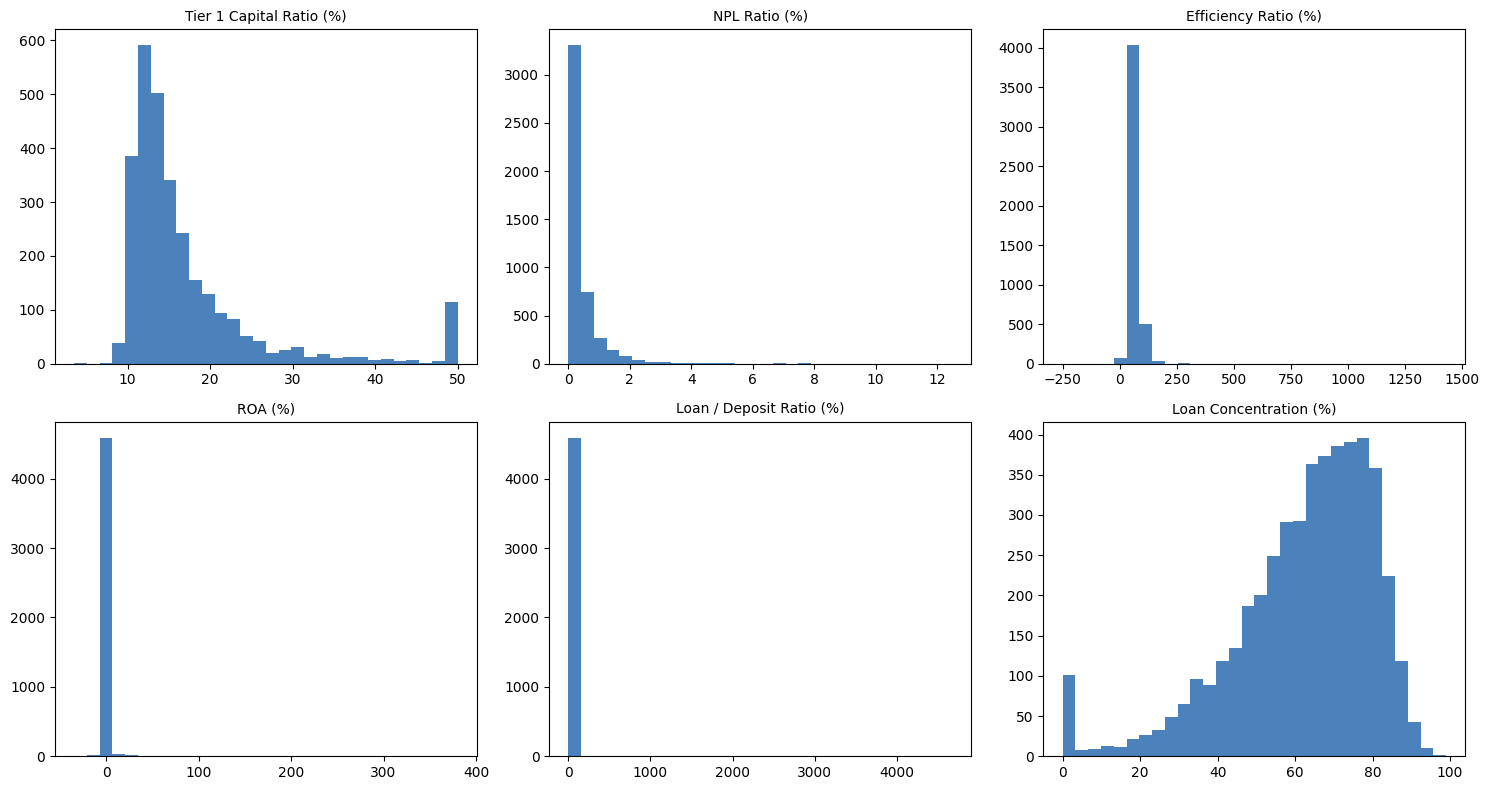

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
comp_display = {
    "tier1_ratio": "Tier 1 Capital Ratio (%)", "npl_ratio": "NPL Ratio (%)",
    "efficiency_ratio": "Efficiency Ratio (%)", "roa": "ROA (%)",
    "loan_deposit_ratio": "Loan / Deposit Ratio (%)", "loan_concentration": "Loan Concentration (%)",
}
for ax, (col, label) in zip(axes.ravel(), comp_display.items()):
    finite_vals = camel[col].replace([float("inf"), float("-inf")], pd.NA).dropna()
    ax.hist(finite_vals, bins=30, color="#2b6cb0", alpha=0.85)
    ax.set_title(label, fontsize=10)
plt.tight_layout()
plt.savefig("camel_component_distributions.png", dpi=110)
plt.show()


## 4. Class imbalance — how rare is `failed`?

This single number drives every modeling decision in Phase 3: which metrics to trust (never plain accuracy), whether to use `class_weight="balanced"`, and how to read a confusion matrix — see "Class imbalance" in [`../docs/01_glossary.md`](../docs/01_glossary.md).

In [5]:
fail_rate = camel["failed"].mean()
print(f"Failed: {camel['failed'].sum()} of {len(camel)} banks ({fail_rate:.1%}).")
camel["failed"].value_counts().rename({0: "healthy", 1: "failed"})


Failed: 15 of 4658 banks (0.3%).


failed
healthy    4643
failed       15
Name: count, dtype: int64

## 5. Does the composite score separate failed from healthy banks?

The single most important validation chart in the whole pipeline (see `00_dataset_research.ipynb` Section 5) — repeated here because it's also the right *last* EDA check before Phase 3 trains a real model on top of these features.

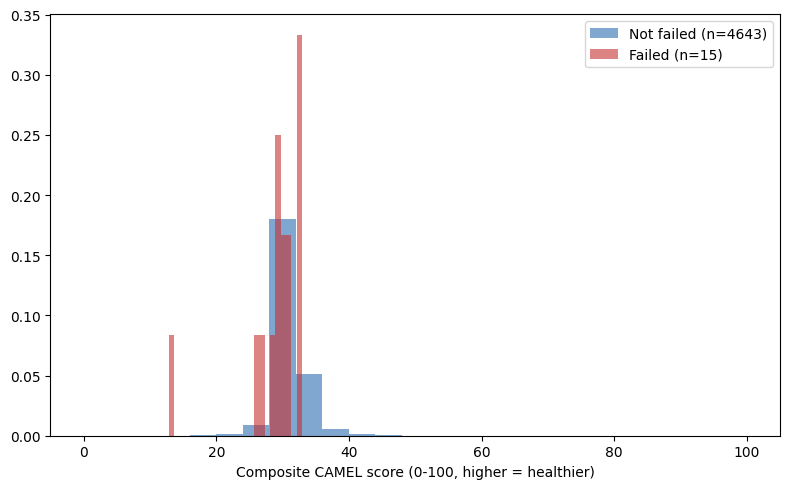

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for flag, label, color in [(0, "Not failed", "#2b6cb0"), (1, "Failed", "#c53030")]:
    subset = camel.loc[camel["failed"] == flag, "composite_score_0_100"]
    ax.hist(subset, bins=25, alpha=0.6, label=f"{label} (n={len(subset)})", color=color, density=True)
ax.set_xlabel("Composite CAMEL score (0-100, higher = healthier)")
ax.legend()
plt.tight_layout()
plt.savefig("camel_composite_separation.png", dpi=110)
plt.show()


## 6. What's next

EDA confirms the feature table is trustworthy enough to model. Phase 3 (`02_baseline_modeling.ipynb`) trains the first real model — a `RandomForestClassifier` predicting `failed` — using [`../src/camel_sentinel/models/baseline.py`](../src/camel_sentinel/models/baseline.py). See [`../docs/03_module_mapping.md`](../docs/03_module_mapping.md) for how the remaining phases (tuning, XAI, RAI, federated, agent, backend/UI) follow after that.